In [2]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from pathlib import Path 

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## Poster plots

Using `word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout` model

In [3]:
# Get model activation files 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB.h5")
path  = Path("binaural_model_attn_stage_reps/word_task_conventional_layer_order/word_task_conventional_layer_order_model_activations_0dB_w_cues_and_corrs_v3.h5")

In [4]:
# outfig_dest = Path('CCN_2024/figures')
# outfig_dest.mkdir(parents=True, exist_ok=True)

In [5]:
h5 = h5py.File(path, 'r')

In [6]:
eg_ix = 0 
fg = h5['conv_block_5_fg_no_cue'][eg_ix]
bg = h5['conv_block_5_bg_no_cue'][eg_ix]

In [7]:
rel_act = np.log(fg) - np.log(bg)
print(rel_act.shape)
# only get bins that are valid - no infs nor nans 
good_rel_act = rel_act[np.isfinite(rel_act)]

(244224,)


/tmp/ipykernel_706704/1542924040.py:1: RuntimeWarning: divide by zero encountered in log
  rel_act = np.log(fg) - np.log(bg)
/tmp/ipykernel_706704/1542924040.py:1: RuntimeWarning: invalid value encountered in subtract
  rel_act = np.log(fg) - np.log(bg)


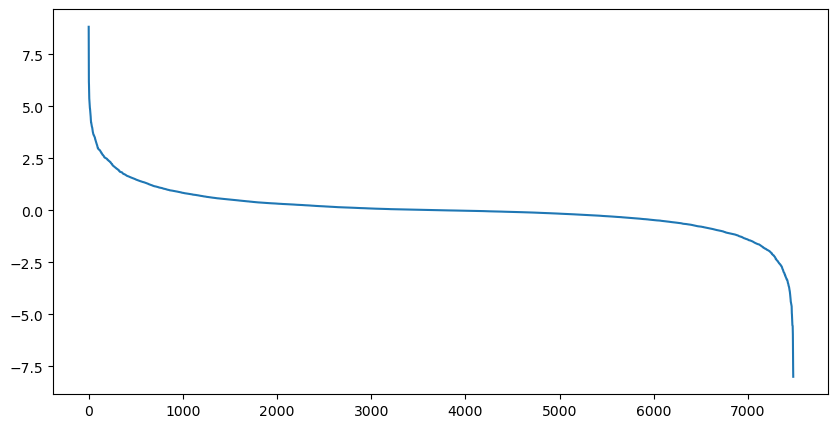

In [8]:
ixs = good_rel_act.argsort()[::-1]

# plot the distribution of relative activations in order 
plt.figure(figsize=(10, 5))
plt.plot(good_rel_act[ixs])

### Correlations pre-computed

Load for wanted analysis: 
* corr(target_no_cue, mixture)
* corr(distractor_no_cue, mixture)

Will also load pre-computed cosine similarity

In [9]:
with h5py.File(path, 'r') as acts:
    ## Get keys with corr in them 
    layer_names = sorted(set([key.split("_fg")[0] for key in acts.keys() if "fg" in key])) # set to remove duplicates 
    print(layer_names)

    dfs = []
    for layer in layer_names:
        data_dict = {}

        if layer != 'cochleagram':
            # get values for uncued single source vs cued mixture
            data_dict['fg_corrs'] = acts[f"{layer}_fg_mixture_corr_no_cue"][:, 0]
            data_dict['bg_corrs'] = acts[f"{layer}_bg_mixture_corr_no_cue"][:, 0]
            data_dict['fg_cos'] = acts[f"{layer}_fg_mixture_cos_no_cue"][:]
            data_dict['bg_cos'] = acts[f"{layer}_bg_mixture_cos_no_cue"][:]
        elif layer == 'cochleagram':
            # get values for single source vs mixture cochleagrams
            data_dict['fg_corrs'] = acts[f"{layer}_fg_mixture_corr"][:, 0]
            data_dict['bg_corrs'] = acts[f"{layer}_bg_mixture_corr"][:, 0]
            data_dict['fg_cos'] = acts[f"{layer}_fg_mixture_cos"][:]
            data_dict['bg_cos'] = acts[f"{layer}_bg_mixture_cos"][:]

        data_dict['layer'] = [layer]*len(acts[f"{layer}_fg_mixture_corr"])

        df = pd.DataFrame(data_dict)
        dfs.append(df)
act_results  = pd.concat(dfs)

act_results['layer'] = act_results['layer'].str.replace('_block_', '')

act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]], id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")
act_cos = pd.melt(act_results[[col for col in act_results.columns if 'corr' not in col]], id_vars =['layer'], value_vars=['fg_cos', 'bg_cos'], var_name='Stream',
                            value_name="Cosine similarity")

# merge 

act_corrs['Stream'].replace('fg_corrs','corr(target$_i$, mixture$_i$)',inplace=True)
act_corrs['Stream'].replace('bg_corrs','corr(distractor$_i$, mixture$_i$)',inplace=True)

# same as above but cos instead of corrs 
act_cos['Stream'].replace('fg_cos', 'sim(target$_i$, mixture$_i$)', inplace=True)
act_cos['Stream'].replace('bg_cos', 'sim(distractor$_i$, mixture$_i$)', inplace=True)

act_corrs['layer'].replace('cochleagram','cochlea',inplace=True)



['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']


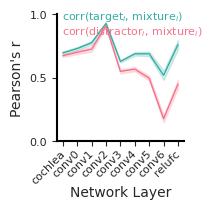

In [16]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())
plt.rc('font', family='Helvetica')

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)', ]#'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],
                'corr(target$_i$, target$_j$)': 'k',
                'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',
                   'corr(target$_i$, target$_j$)': '--',
                   'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line',data=act_corrs, x='layer', y="Pearson's r", #order=order,
              hue = 'Stream', hue_order = hue_order, palette=palette_dict, 
              height=2, aspect=2, 
            #   err_style='bars', err_kws={'elinewidth': 1},
              errorbar=('se', 2), seed=1)
            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=10
tick_fontsize = 8

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 


p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
yticks = np.linspace(0,1,3).round(1)
ratio = 1.0
# increase axis thickness and set to square aspect

line_thickness = 1.5

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(1)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
p._legend.remove()
# add text 
p.fig.text(0.305, 0.9, 'corr(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(target$_i$, mixture$_i$)'], ha='left');
p.fig.text(0.305, 0.825, 'corr(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')



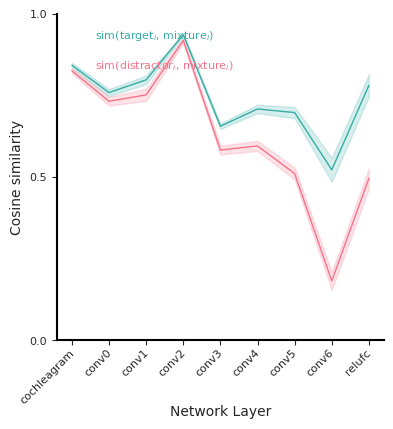

In [14]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())
plt.rc('font', family='Helvetica')

hue_order = ['sim(target$_i$, mixture$_i$)', 'sim(distractor$_i$, mixture$_i$)', ]#'sim(target$_i$, target$_j$)', 'sim(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'sim(target$_i$, mixture$_i$)': palette[1],
                'sim(distractor$_i$, mixture$_i$)': palette[0],
                'sim(target$_i$, target$_j$)': 'k',
                'sim(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'sim(target$_i$, mixture$_i$)': '-',
                   'sim(distractor$_i$, mixture$_i$)': '-',
                   'sim(target$_i$, target$_j$)': '--',
                   'sim(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line',data=act_cos, x='layer', y="Cosine similarity", #order=order,
              hue = 'Stream', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=2, 
            #   err_style='bars', err_kws={'elinewidth': 1},
              errorbar=('se', 2), seed=1)
            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=10
tick_fontsize = 8

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 


p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
yticks = np.linspace(0,1,3).round(1)
ratio = 1.0
# increase axis thickness and set to square aspect

line_thickness = 1.5

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(1)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
p._legend.remove()
# add text 
p.fig.text(0.305, 0.9, 'sim(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['sim(target$_i$, mixture$_i$)'], ha='left');
p.fig.text(0.305, 0.825, 'sim(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['sim(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')

